This notebook creates the intrinsic tokenizer metrics figures in the Appendix, pass `METRIC_NAME` from pcw, fertility, and parity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from toksuite.logging.plot_utils import MODEL_TO_COLOR, setup_styles

%matplotlib inline

setup_styles()

In [2]:
METRIC_NAME = "pcw"
METRIC_NAME = "fertility"
METRIC_NAME = "parity"
results_file = (
    Path().resolve().parent.absolute()
    / "results"
    / "intrinsic_metrics"
    / f"{METRIC_NAME}.csv"
)
OUTPUT_DIR = (
    Path().resolve().parent.absolute() / "results" / "paper" / "intrinsic_metrics"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_file

PosixPath('/Users/gsaltintas/code/phd/TokSuite/results/intrinsic_metrics/parity.csv')

In [3]:
# Read the CSV file
df = pd.read_csv(results_file)
df.head()

,Column 6,model_name,zho_Hans,tur_Latn,pes_Arab,ita_Latn
0,common-pile-comma-v0.1,Comma,1.942,2.212,4.314,1.869
1,meta-llama-Llama-3.2-1B,Llama-3.2,1.288,1.390,1.521,1.623
2,microsoft-Phi-3-mini-4k-instruct,Phi-3,2.029,2.110,4.078,1.481
3,gpt2,GPT-2,3.211,2.447,5.352,2.017
4,tiktoken-gpt-4o,GPT-4o,1.266,1.433,1.555,1.469


In [4]:
# Languages (columns) to plot
languages = {
    "eng_Latn": "English",
    "zho_Hans": "Chinese",
    "tur_Latn": "Turkish",
    "pes_Arab": "Persian",
    "ita_Latn": "Italian",
}

if METRIC_NAME == "parity":
    languages = {
        "zho_Hans": "Chinese",
        "tur_Latn": "Turkish",
        "pes_Arab": "Persian",
        "ita_Latn": "Italian",
    }


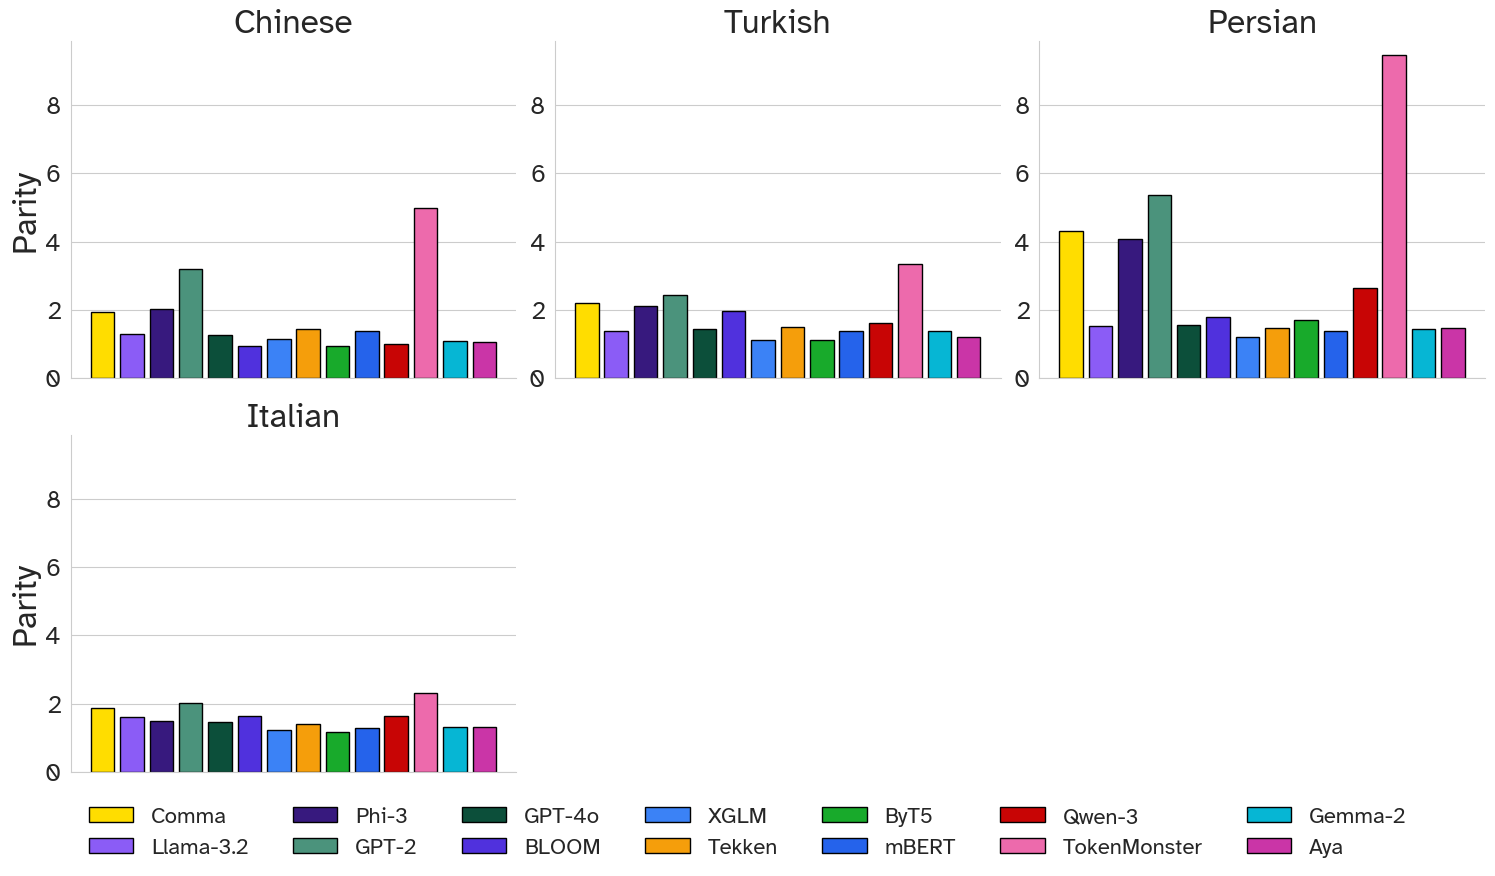

In [5]:
# Get model names
models = df["model_name"].tolist()
num_models = len(models)
color_map = MODEL_TO_COLOR
# Get colors for each model, use default color if model not in map
colors = [color_map.get(model, "#999999") for model in models]


def clean_up(ax):
    sns.despine()
    ax.tick_params(direction="out", which="both")
    ax.set_xticks([])


# Create subplots - 2 rows, 3 columns (3 on top, 2 on bottom)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

# Find global min and max across all languages for consistent y-axis
all_values = []
for lang_code in languages.keys():
    all_values.extend(df[lang_code].tolist())
global_min = min(all_values)
global_max = max(all_values)

for idx, (lang_code, lang_name) in enumerate(languages.items()):
    ax = axs[idx]

    # Get values for this language
    values = df[lang_code].tolist()

    # Create bar positions
    x_pos = np.arange(num_models)

    # Create bars
    bars = ax.bar(x_pos, values, edgecolor="k", linewidth=1, color=colors)

    # Set title and labels
    ax.set_title(lang_name, fontsize=24)
    if METRIC_NAME == "fertility":
        ax.set_ylabel("Fertility" if idx % 3 == 0 else "", fontsize=24)
    elif METRIC_NAME == "parity":
        ax.set_ylabel("Parity" if idx % 3 == 0 else "", fontsize=24)
    elif METRIC_NAME == "pcw":
        ax.set_ylabel("PCW" if idx % 3 == 0 else "", fontsize=24)
    else:
        ax.set_ylabel(METRIC_NAME if idx % 3 == 0 else "", fontsize=20)

    # Use consistent y-axis limits across all subplots
    score_range = global_max - global_min
    ax.set_ylim(0, global_max + 0.05 * score_range)

    clean_up(ax)

# Hide the last subplot (since we only have 5 languages)
axs[5].set_visible(False)

if METRIC_NAME == "parity":
    axs[4].set_visible(False)


fig.tight_layout(pad=0.5)


# Create legend with model names
fig.legend(
    bars,
    models,
    ncols=min(7, num_models),
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    fontsize=16,
)

plt.savefig(OUTPUT_DIR / f"{METRIC_NAME}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()